# KLA - Baseline NAFNet Training

Degraded Input -> Normalisation -> Degradataion Encoder -> NAFNet -> Charbonnier loss

In [1]:
import os
import sys
import time
import dataclasses
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import grain
from flax import nnx
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


In [2]:
TRAIN_PATH = "../train"
TEST_PATH = "../NoisyLR"

TRAIN_LR_PATH = os.path.join(TRAIN_PATH, "NoisyLR")
TEST_LR_PATH = TEST_PATH
TRAIN_GT_PATH = os.path.join(TRAIN_PATH, "GT")


In [3]:
@dataclasses.dataclass
class TrainConfig:
    train_noisy_dir: str
    train_gt_dir: str
    batch_size: int = 8
    worker_count: int = 1
    seed: int = 42

    in_channels: int = 1
    out_channels: int = 1
    hidden_dim: int = 32
    num_blocks: int = 4
    upsample_scale: int = 2

    deg_hidden_dim: int = 16
    deg_embed_dim: int = 8

    normalization: str = "none"

    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0

    num_epochs: int = 100
    val_split: float = 0.1

    ckpt_dir: str = "checkpoints"
    ckpt_every_epochs: int = 5
    max_to_keep: int = 2

    log_every_steps: int = 20
    loss_func: str = "Huber"


cfg = TrainConfig(
    train_noisy_dir=TRAIN_LR_PATH,
    train_gt_dir=TRAIN_GT_PATH,
    batch_size=16,
    hidden_dim=32,
    num_blocks=6,
    num_epochs=50,
    ckpt_dir="./checkpoints",
    ckpt_every_epochs=5,
)


In [4]:
from model_util import *
sys.path.insert(0, str(Path().resolve().parent))

from train_utils import *
from dataloader import create_src_dataloader
from Proposal_3.model_util import *

In [5]:
EPS = 1e-6


def zscore_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    mean = jnp.mean(x, axis=axis, keepdims=True)
    std = jnp.std(x, axis=axis, keepdims=True)
    return (x - mean) / (std + eps)


def zscore_denormalize(x_norm: jax.Array, mean: jax.Array, std: jax.Array, eps: float = EPS) -> jax.Array:
    return x_norm * (std + eps) + mean


def asinh_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    median = jnp.median(x, axis=axis, keepdims=True)
    q75 = jnp.quantile(x, 0.75, axis=axis, keepdims=True)
    q25 = jnp.quantile(x, 0.25, axis=axis, keepdims=True)
    iqr = q75 - q25
    return jnp.arcsinh((x - median) / (iqr + eps))


def asinh_denormalize(x_norm: jax.Array, median: jax.Array, iqr: jax.Array, eps: float = EPS) -> jax.Array:
    return jnp.sinh(x_norm) * (iqr + eps) + median


# Registry so the train script can select strategy by name from config,
# without importing every function individually.
NORMALIZERS: dict[str, Callable[..., jax.Array]] = {
    "zscore": zscore_normalize,
    "asinh": asinh_normalize,
    "none": lambda x, **kwargs: x,
}


def get_normalizer(name: str) -> Callable[..., jax.Array]:
    if name not in NORMALIZERS:
        raise ValueError(f"Unknown normalizer '{name}'. Options: {list(NORMALIZERS)}")
    return NORMALIZERS[name]


In [6]:
# ── File listing + train/val split ──────────────────────────────────────

all_noisy = sorted(Path(cfg.train_noisy_dir).glob("*.npy"))
all_gt    = sorted(Path(cfg.train_gt_dir).glob("*.npy"))
assert len(all_noisy) == len(all_gt), (
    f"Mismatch: {len(all_noisy)} noisy files vs {len(all_gt)} GT files"
)

train_noisy, val_noisy, train_gt, val_gt = train_test_split(
    all_noisy, all_gt,
    test_size=cfg.val_split, random_state=cfg.seed,
)

# ---- Add Synthetic Dataset to Train ONLY ----
synth_noisy = sorted(Path("data/synthetic/NoisyLR").glob("*.npy"))
synth_gt = sorted(Path("data/synthetic/GT").glob("*.npy"))
if len(synth_noisy) > 0:
    train_noisy.extend(synth_noisy)
    train_gt.extend(synth_gt)
    print(f"Added {len(synth_noisy)} synthetic pairs to training.")
# ---------------------------------------------

# ── Build dataloaders ───────────────────────────────────────────────────

train_src, train_loader = create_src_dataloader(
    train_noisy, train_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed, shuffle=True, augment=True,
)

val_src, val_loader = create_src_dataloader(
    val_noisy, val_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed + 1, shuffle=False, augment=False,
)

train_steps_per_epoch = len(train_src) // cfg.batch_size
val_steps_per_epoch   = len(val_src) // cfg.batch_size

print(f"Train: {len(train_src)} samples → {train_steps_per_epoch} steps/epoch")
print(f"Val:   {len(val_src)} samples → {val_steps_per_epoch} steps/epoch")


Added 16000 synthetic pairs to training.


Train: 18880 samples → 1180 steps/epoch
Val:   320 samples → 20 steps/epoch


In [7]:
def build_checkpoint_manager(ckpt_dir, max_to_keep=2):
    options = ocp.CheckpointManagerOptions(
        max_to_keep=max_to_keep,
        save_interval_steps=1,  
        create=True,
        enable_async_checkpointing=True,
    )
    ckpt_dir = Path(ckpt_dir).resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ocp.CheckpointManager(str(ckpt_dir), options=options)


def save_checkpoint(manager, step, model, optimizer, epoch, train_loss):
    _, model_state = nnx.split(model)
    _, opt_state = nnx.split(optimizer)
    metadata = {"epoch": epoch, "step": step, "train_loss": float(train_loss)}

    manager.save(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardSave(model_state),
            opt_state=ocp.args.StandardSave(opt_state),
            metadata=ocp.args.JsonSave(metadata),
        ),
    )


def restore_checkpoint(manager, step, model, optimizer):
    _, abstract_model_state = nnx.split(nnx.eval_shape(lambda: model))
    _, abstract_opt_state = nnx.split(nnx.eval_shape(lambda: optimizer))

    restored = manager.restore(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardRestore(abstract_model_state),
            opt_state=ocp.args.StandardRestore(abstract_opt_state),
            metadata=ocp.args.JsonRestore(),
        ),
    )
    nnx.update(model, restored.model_state)
    nnx.update(optimizer, restored.opt_state)
    return dict(restored.metadata)

In [8]:
rngs = nnx.Rngs(cfg.seed)
model = Restoration_Pipeline_P3(
    in_channels=cfg.in_channels,
    out_channels=cfg.out_channels,
    hidden_dim=cfg.hidden_dim,
    num_blocks=cfg.num_blocks,
    upsample_scale=cfg.upsample_scale,
    deg_hidden_dim=cfg.deg_hidden_dim,
    deg_embed_dim=cfg.deg_embed_dim,
    rngs=rngs,
    num_experts=3,
)
warmup = 2000
total_train_steps = train_steps_per_epoch * cfg.num_epochs

schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=cfg.learning_rate,
    warmup_steps=warmup, decay_steps=total_train_steps - warmup, end_value=1e-6,
)

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

normalizer_fn = NORMALIZERS["none"]

ckpt_manager = build_checkpoint_manager(cfg.ckpt_dir, max_to_keep=cfg.max_to_keep)
print(f"[hardware] backend={jax.default_backend()} devices={jax.devices()}")
print(f"[schedule] warmup={warmup}  total_steps={total_train_steps}")


[hardware] backend=gpu devices=[CudaDevice(id=0)]
[schedule] warmup=2000  total_steps=59000


In [9]:
global_step = 0

for epoch in range(cfg.num_epochs):
    train_iter = iter(train_loader)
    val_iter   = iter(val_loader)
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    epoch_train_losses = []
    pbar = tqdm(range(train_steps_per_epoch), desc=f"Epoch {epoch:03d} [train]", leave=False)
    for step_in_epoch in pbar:
        raw_batch = to_device(next(train_iter))

        # --- preprocessing (outside JIT) ---
        noisy = raw_batch["noisy_lr"].astype(jnp.float32)

        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        loss = train_step(model, optimizer, x_norm, gt)
        epoch_train_losses.append(float(loss))
        global_step += 1

        pbar.set_postfix(loss=f"{float(loss):.5f}")

    train_loss_mean = float(np.mean(epoch_train_losses))

    # ── Validate ──────────────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
    for _ in pbar_val:
        raw_batch = to_device(next(val_iter))

        noisy = raw_batch["noisy_lr"].astype(jnp.float32)
        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        v_loss, _ = val_step(model, x_norm, gt)
        epoch_val_losses.append(float(v_loss))

        pbar_val.set_postfix(val_loss=f"{float(v_loss):.5f}")

    val_loss_mean = float(np.mean(epoch_val_losses))

    # ── Epoch summary ─────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    print(
        f"[epoch {epoch:03d}] "
        f"train_loss={train_loss_mean:.5f}  "
        f"val_loss={val_loss_mean:.5f}  "
        f"time={epoch_time:.1f}s"
    )

    if (epoch + 1) % cfg.ckpt_every_epochs == 0 or epoch == cfg.num_epochs - 1:
        save_checkpoint(ckpt_manager, global_step, model, optimizer, epoch, train_loss_mean)
        print(f"  [checkpoint] saved at step {global_step} (epoch {epoch})")

ckpt_manager.wait_until_finished()
ckpt_manager.close()
print("[done] training complete.")


Epoch 000 [train]:   0%|          | 0/1180 [00:00<?, ?it/s]

Epoch 000 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

[epoch 000] train_loss=0.07229  val_loss=0.04386  time=179.0s


Epoch 001 [train]:   0%|          | 0/1180 [00:00<?, ?it/s]

Epoch 001 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 037 [train]:   0%|          | 0/1180 [00:00<?, ?it/s]

Epoch 037 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

[epoch 037] train_loss=0.04025  val_loss=0.03811  time=123.0s


Epoch 038 [train]:   0%|          | 0/1180 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
restore_checkpoint(ckpt_manager,step=41300,model=model,optimizer=optimizer)

model.eval()
final_metrics=[]
SSIM_metric=[]
PSNR_metric=[]
LPIPS_metric=[]
pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
for _ in pbar_val:
    raw_batch = to_device(next(val_iter))

    noisy = raw_batch["noisy_lr"].astype(jnp.float32)
    gt    = raw_batch["gt"].astype(jnp.float32)
    x_norm = normalizer_fn(noisy, axis=(1, 2))
    metrics, _ = metric_val_step(model, x_norm, gt)
    SSIM_metric.append(metrics[0])
    PSNR_metric.append(metrics[1])
    LPIPS_metric.append(metrics[2])
    final_metrics.append(metrics)

print(f"mean SSIM:{np.mean(SSIM_metric)}")
print(f"mean PSNR:{np.mean(PSNR_metric)}")
print(f"mean LPIPS:{np.mean(LPIPS_metric)}")

mean SSIM:0.9349470138549805
mean PSNR:27.794076919555664
mean LPIPS:0.29742035269737244


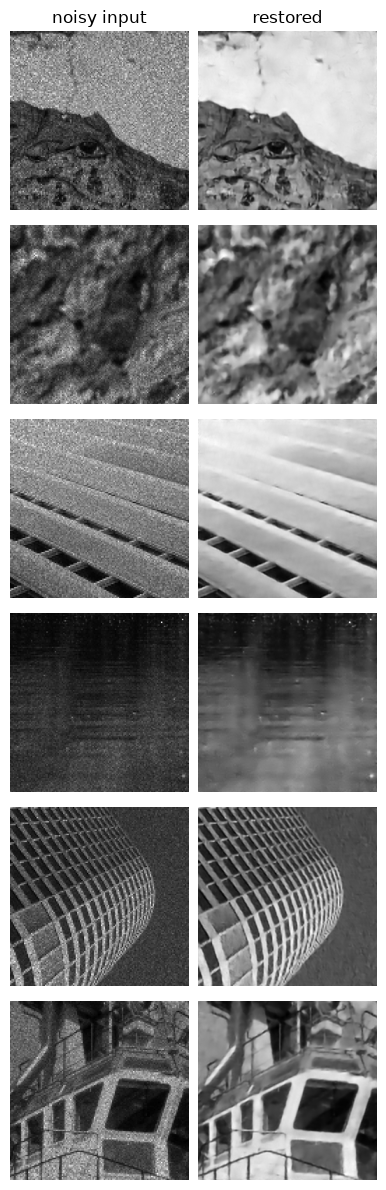

In [ ]:
import matplotlib.pyplot as plt
# restore_checkpoint(ckpt_manager, ckpt_manager.latest_step(), model, optimizer)
test_files = sorted(Path(TEST_LR_PATH).glob("*.npy"))[:6]
test_imgs = np.stack([np.load(f) for f in test_files])[..., None].astype(np.float32)  # (N,H,W,1)

# --- preprocessing (outside JIT) ---
noisy = to_device({"noisy_lr": test_imgs})["noisy_lr"]
x_norm = normalizer_fn(noisy, axis=(1, 2))

pred, _z_d = model(x_norm)

n = min(50, len(test_files))
fig, ax = plt.subplots(n, 2, figsize=(4, 2 * n))
for i in range(n):
    ax[i, 0].imshow(noisy[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["noisy input", "restored"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()


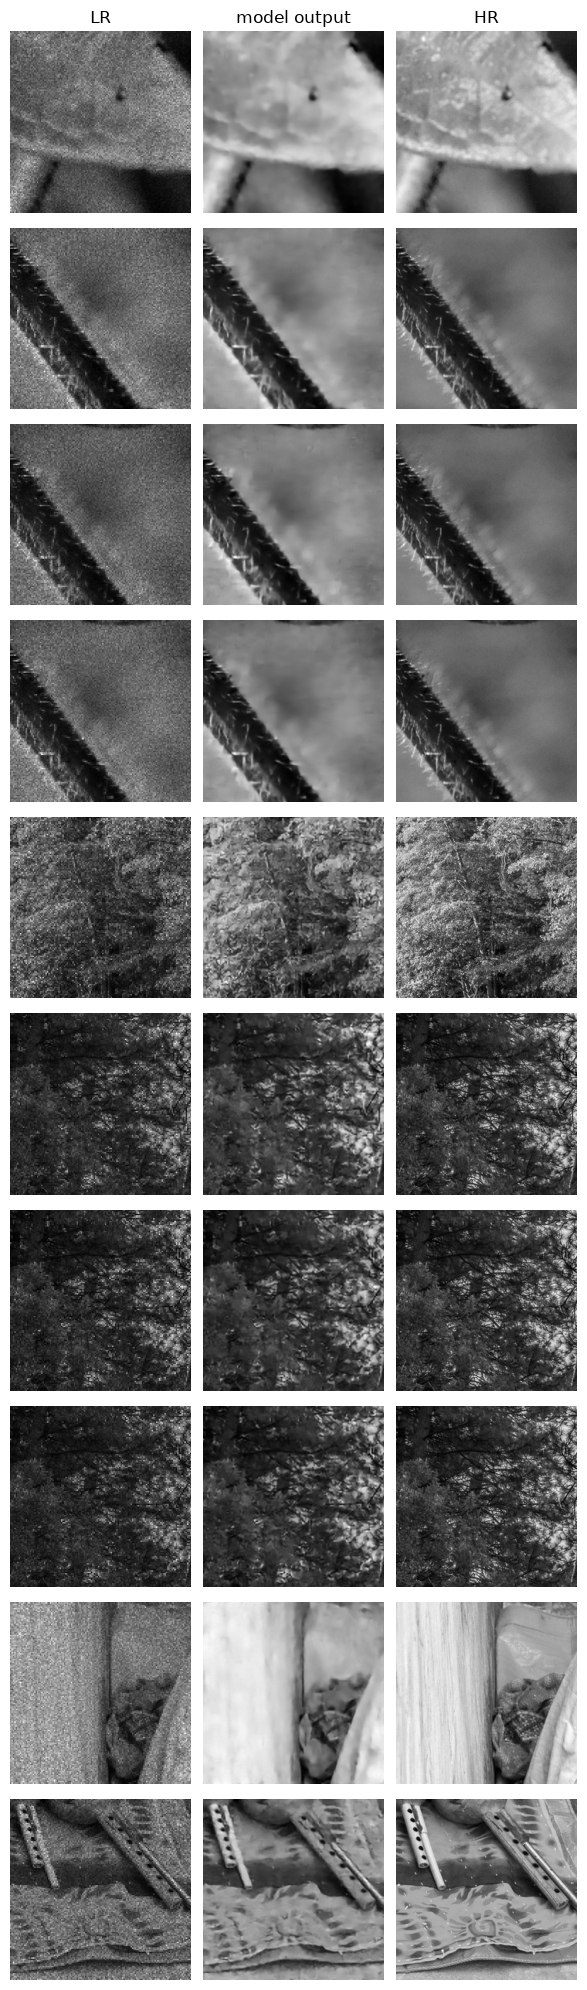

In [ ]:
lr_files = sorted(Path(TRAIN_LR_PATH).glob("*.npy"))[20:30]
gt_files = sorted(Path(TRAIN_GT_PATH).glob("*.npy"))[20:30]

lr_imgs = np.stack([np.load(f) for f in lr_files])[..., None].astype(np.float32)
hr_imgs = np.stack([np.load(f) for f in gt_files])[..., None].astype(np.float32)

# --- preprocessing (outside JIT) ---
lr = to_device({"noisy_lr": lr_imgs})["noisy_lr"]
hr = to_device({"gt": hr_imgs})["gt"]
x_norm = normalizer_fn(lr, axis=(1, 2))

pred, _z_d = model(x_norm)

n = len(lr_files)
fig, ax = plt.subplots(n, 3, figsize=(6, 2 * n))
for i in range(n):
    ax[i, 0].imshow(lr[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
    ax[i, 2].imshow(hr[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["LR", "model output", "HR"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()
